<a href="https://colab.research.google.com/github/morenakukurin/Repo_AIbio/blob/4.-vela/MLR_vjezba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Multiple linear regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/regression_data.csv')
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [4]:
dataset

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [15]:
imena = X.columns.to_list()
imena[0] = 'proba'
imena[0] = 'AT'

In [16]:
y.name='NO2'
y

,NO2
0,463.26
1,444.37
2,488.56
3,446.48
4,473.90
...,...
9563,460.03
9564,469.62
9565,429.57
9566,435.74


In [17]:
import seaborn as sns

<Axes: xlabel='NO2', ylabel='Count'>

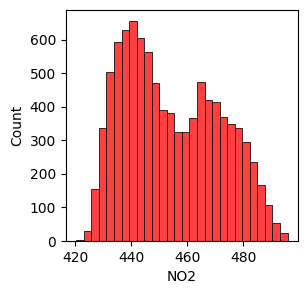

In [21]:
from matplotlib import markers
plt.figure(figsize=(3,3))
sns.histplot(y, color = 'red')

<Axes: >

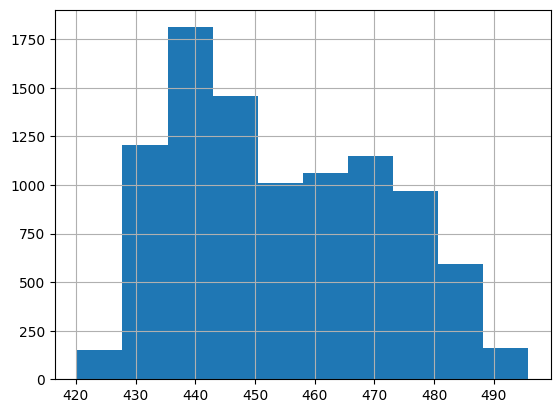

In [20]:
y.hist()

In [22]:
dataset.corr()

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


<Axes: >

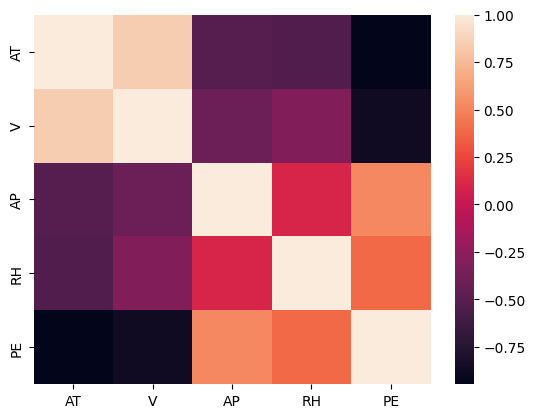

In [23]:
sns.heatmap(dataset.corr())

In [25]:
dataset.cov()

,AT,V,AP,RH,PE
AT,55.539357,79.941324,-22.463437,-59.032171,-120.593715
V,79.941324,161.490544,-31.206771,-57.922808,-188.642778
AP,-22.463437,-31.206771,35.269152,8.633874,52.546510
RH,-59.032171,-57.922808,8.633874,213.167848,97.129952
PE,-120.593715,-188.642778,52.546510,97.129952,291.282318


#Splitanje

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state = 0)

#definiranje modela

In [28]:
mlr = LinearRegression()
mlr

LinearRegression()

In [29]:
mlr.fit(X_train,y_train)

LinearRegression()

In [31]:
y_pred = mlr.predict(X_test)
y_pred

array([431.43458966, 458.57522935, 462.76604909, ..., 473.74893817,
       475.43985731, 442.01760971])

In [42]:
y_pred = pd.Series(y_pred, index = y_test.index, name = 'y_pred')
y_pred

,y_pred
4834,431.434590
1768,458.575229
2819,462.766049
7779,448.606498
7065,457.876052
...,...
4987,442.769494
4688,454.897695
3964,473.748938
3359,475.439857


In [44]:
pd.concat([y_test,y_pred], axis=1)

,NO2,y_pred
4834,431.23,431.434590
1768,460.01,458.575229
2819,461.14,462.766049
7779,445.90,448.606498
7065,451.29,457.876052
...,...,...
4987,434.38,442.769494
4688,451.97,454.897695
3964,468.90,473.748938
3359,473.90,475.439857


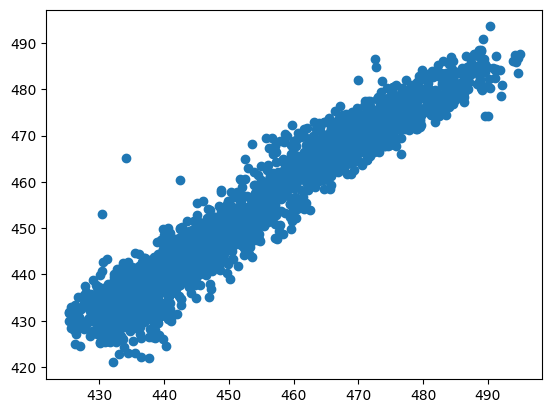

In [45]:
plt.scatter(y_test, y_pred)

#evaluacija

In [48]:
print(f'mse = {mean_squared_error(y_test,y_pred):.2f},\nmae = {mean_absolute_error(y_test, y_pred):.2f},\nr2 = {r2_score(y_test,y_pred):.2f},\nrmse = {np.sqrt(mean_squared_error(y_test,y_pred)):.2f}')



mse = 19.83,
mae = 3.56,
r2 = 0.93,
rmse = 4.45


In [49]:
mlr.coef_

array([-1.96950789, -0.23767112,  0.06473976, -0.15782574])

In [50]:
mlr.intercept_

np.float64(451.949503920339)